# Q-learning: glucose & reward within an episode

Train the agent as in `QLearningAgent.train`, but also record step-by-step glucose and reward for a few representative episodes, then plot those trajectories.

In [1]:
%load_ext autoreload
%autoreload 2

# allows to import modules from root directory
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

from GridWorld import GridWorld, Action
from QLearningAgent import QLearningAgent

## Setup
Same parameters as the `__main__` block of `QLearningAgent.py`.

In [3]:
SEED = None

env = GridWorld(grid_size=8, glucose_target=50, glucose_max=100,
                n_food=20, max_steps=200, metabolism_rate=5, intake_amount=10,
                drive_n=2, drive_m=1, seed=SEED)
agent = QLearningAgent(n_actions=env.n_actions, alpha=0.3, gamma=0.95,
                       epsilon_start=1.0, epsilon_min=0.05, epsilon_decay=0.9,
                       seed=SEED)

N_EPISODES = 5000
# episodes whose full step-by-step trajectory we keep
RECORD_EPISODES = [0, 10, 100, 1000, N_EPISODES - 1]

## Training with trajectory logging
`run_episode` mirrors the inner loop of `train()`, but logs glucose, reward, action, agent position, and food eaten at every step.

Each step is put into one of three action categories:
- **move**: UP / DOWN / LEFT / RIGHT
- **eat**: EAT (only allowed on a food tile, so it always consumes food)
- **idle**: IDLE

The environment masks actions: `obs["valid_actions"]` lists what's allowed from the current tile, and the agent only chooses (and bootstraps its Q-update) from those.

Per-episode category counts and food left at the end are kept for every episode; full trajectories only for `RECORD_EPISODES`.

In [4]:
# action categories used in every action plot; each keeps its color across figures
ACTION_CATS = ["move", "eat", "idle"]
CAT_COLORS = {"move": "#2a78d6", "eat": "#eb6834", "idle": "#1baf7a"}


def classify_step(action):
    """
    Maps one step to an action category (see ACTION_CATS).
    """
    if action == Action.EAT:
        return "eat"
    if action == Action.IDLE:
        return "idle"
    return "move"


def run_episode(env, agent, learn=True):
    """
    Runs one episode. If learn=True, updates the Q-table (same as train()).
    Returns a dict of per-step arrays. glucose, positions, and food_left have
    their start-of-episode value at index 0, so they have one more entry than
    reward/actions. Step t (1-based) corresponds to index t-1 of reward/actions.
    """
    obs = env.reset() # reset environment
    state = agent.discretize_state(obs) # convert observation to state for q-learning
    # copy: obs["food_positions"] is env.food_indices itself, which step() edits in place
    food_start = list(obs["food_positions"])
    glucose, rewards, actions = [obs["glucose_level"]], [], []
    positions = [obs["agent_pos"]] # positions[t] is the agent's tile after step t
    food_left = [len(food_start)]
    categories = []
    eaten_at = {} # food tile -> step it was eaten
    done = False
    info = None
    while not done: # run until episode ends
        action = agent.choose_action(state, obs["valid_actions"]) # only actions allowed on this tile
        pos_before = env.agent_pos
        next_obs, reward, done, info = env.step(action) # take a step based on action
        next_state = agent.discretize_state(next_obs)
        if learn: # update Q-table if learning
            agent.update(state, action, reward, next_state, next_obs["valid_actions"])
        state = next_state
        obs = next_obs

        glucose.append(next_obs["glucose_level"])
        rewards.append(reward)
        actions.append(int(action)) # we store all actions taken too
        positions.append(next_obs["agent_pos"])
        food_left.append(len(next_obs["food_positions"]))
        categories.append(classify_step(action))
        if action == Action.EAT:
            eaten_at[pos_before] = len(actions) # EAT doesn't move the agent, so this is the eaten tile
    return {
        "glucose": np.array(glucose),
        "reward": np.array(rewards),
        "cum_reward": np.cumsum(rewards), # adds all the rewards up to this step
        "actions": np.array(actions),
        "categories": np.array(categories),
        "positions": np.array(positions), # (row, col)
        "food_start": food_start,
        "food_left": np.array(food_left),
        "eaten_at": eaten_at,
        "epsilon": agent.epsilon,
        "info": info,
    }


def action_counts(traj):
    """
    Number of steps in each action category for one episode.
    """
    return {cat: int(np.sum(traj["categories"] == cat)) for cat in ACTION_CATS}


episode_total_rewards = [] # will store total reward per episode
episode_lengths = [] # will store how long each episode is (in steps)
episode_action_counts = {cat: [] for cat in ACTION_CATS} # category -> count per episode
episode_food_left = [] # food remaining when each episode ends
trajectories = {}  # episode index -> trajectory dict
for episode in range(N_EPISODES): # looping over num episodes
    traj = run_episode(env, agent, learn=True) # running a full episode
    agent.decay_epsilon() # decay epsilon after each episode
    episode_total_rewards.append(traj["reward"].sum()) # sum over all rewards
    episode_lengths.append(len(traj["reward"])) # a reward for each step; so len(reward) = total steps
    for cat, count in action_counts(traj).items():
        episode_action_counts[cat].append(count)
    episode_food_left.append(traj["food_left"][-1])
    if episode in RECORD_EPISODES:
        trajectories[episode] = traj

for ep, traj in trajectories.items():
    counts = action_counts(traj)
    print(f"episode {ep:>5}: {len(traj['reward']):>3} steps, "
          f"total reward {traj['reward'].sum():8.1f}, eps={traj['epsilon']:.3f}  ({traj['info']})")
    print(f"{'':16}ate {counts['eat']}/{len(traj['food_start'])}, "
          f"idle {counts['idle']}, move {counts['move']}")

episode     0:  12 steps, total reward  -2500.0, eps=1.000  (Agent starved to death.)
                ate 1/20, idle 4, move 7
episode    10:  14 steps, total reward  -2500.0, eps=0.349  (Agent starved to death.)
                ate 2/20, idle 2, move 10
episode   100:  14 steps, total reward  -2500.0, eps=0.050  (Agent starved to death.)
                ate 2/20, idle 3, move 9
episode  1000:  24 steps, total reward  -2500.0, eps=0.050  (Agent starved to death.)
                ate 7/20, idle 2, move 15
episode  4999:  34 steps, total reward  -2500.0, eps=0.050  (Agent starved to death.)
                ate 12/20, idle 0, move 22


## Greedy rollout of the learned policy
Run one episode with epsilon = 0 and no Q-table updates, to see what the learned policy does on its own.

In [5]:
saved_epsilon = agent.epsilon
agent.epsilon = 0.0
greedy_traj = run_episode(env, agent, learn=False)
agent.epsilon = saved_epsilon

greedy_counts = action_counts(greedy_traj)
print(f"greedy: {len(greedy_traj['reward'])} steps, "
      f"total reward {greedy_traj['reward'].sum():.1f}  ({greedy_traj['info']})")
print(f"        ate {greedy_counts['eat']}/{len(greedy_traj['food_start'])}, "
      f"idle {greedy_counts['idle']}, move {greedy_counts['move']}")

greedy: 44 steps, total reward -2500.0  (Agent starved to death.)
        ate 17/20, idle 0, move 27


## Learning curve
Episode length (steps survived) per episode (light) and a moving average (dark); dotted lines mark the recorded episodes.

Note: total reward per episode is not a useful learning signal here. Since reward = drive(t) - drive(t+1), the per-episode sum telescopes to drive(start) - drive(end), so every episode that ends in starvation gets the same total (-2500 with these parameters).

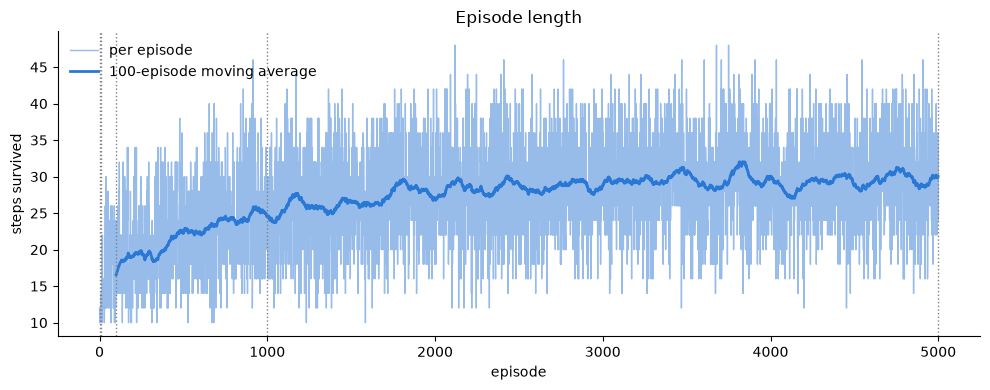

In [6]:
WINDOW = 100
lengths = np.array(episode_lengths)
# compute moving average of episode lengths
# np.ones(WINDOW) / WINDOW creates a window of size WINDOW with equal weights (here 1/100)
# so we multiply each episode length by 1/100 and sum over the window to get the average
moving_avg = np.convolve(lengths, np.ones(WINDOW) / WINDOW, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lengths, color="#97bcea", linewidth=1, label="per episode")
ax.plot(np.arange(WINDOW - 1, len(lengths)), moving_avg, color="#2a78d6", linewidth=2,
        label=f"{WINDOW}-episode moving average")
for ep in RECORD_EPISODES:
    ax.axvline(ep, color="gray", linestyle=":", linewidth=1) # gray lines are recorded episodes
ax.set_xlabel("episode")
ax.set_ylabel("steps survived")
ax.set_title("Episode length")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../plots/episode_lengths.png", dpi=300)
plt.show()

## Glucose and reward over representative episodes
One column per episode. Rows: glucose (dashed line = target; orange ticks = EATs), action strip (EAT and IDLE), food remaining, per-step reward, cumulative reward. Rows share a y-axis so episodes are directly comparable.

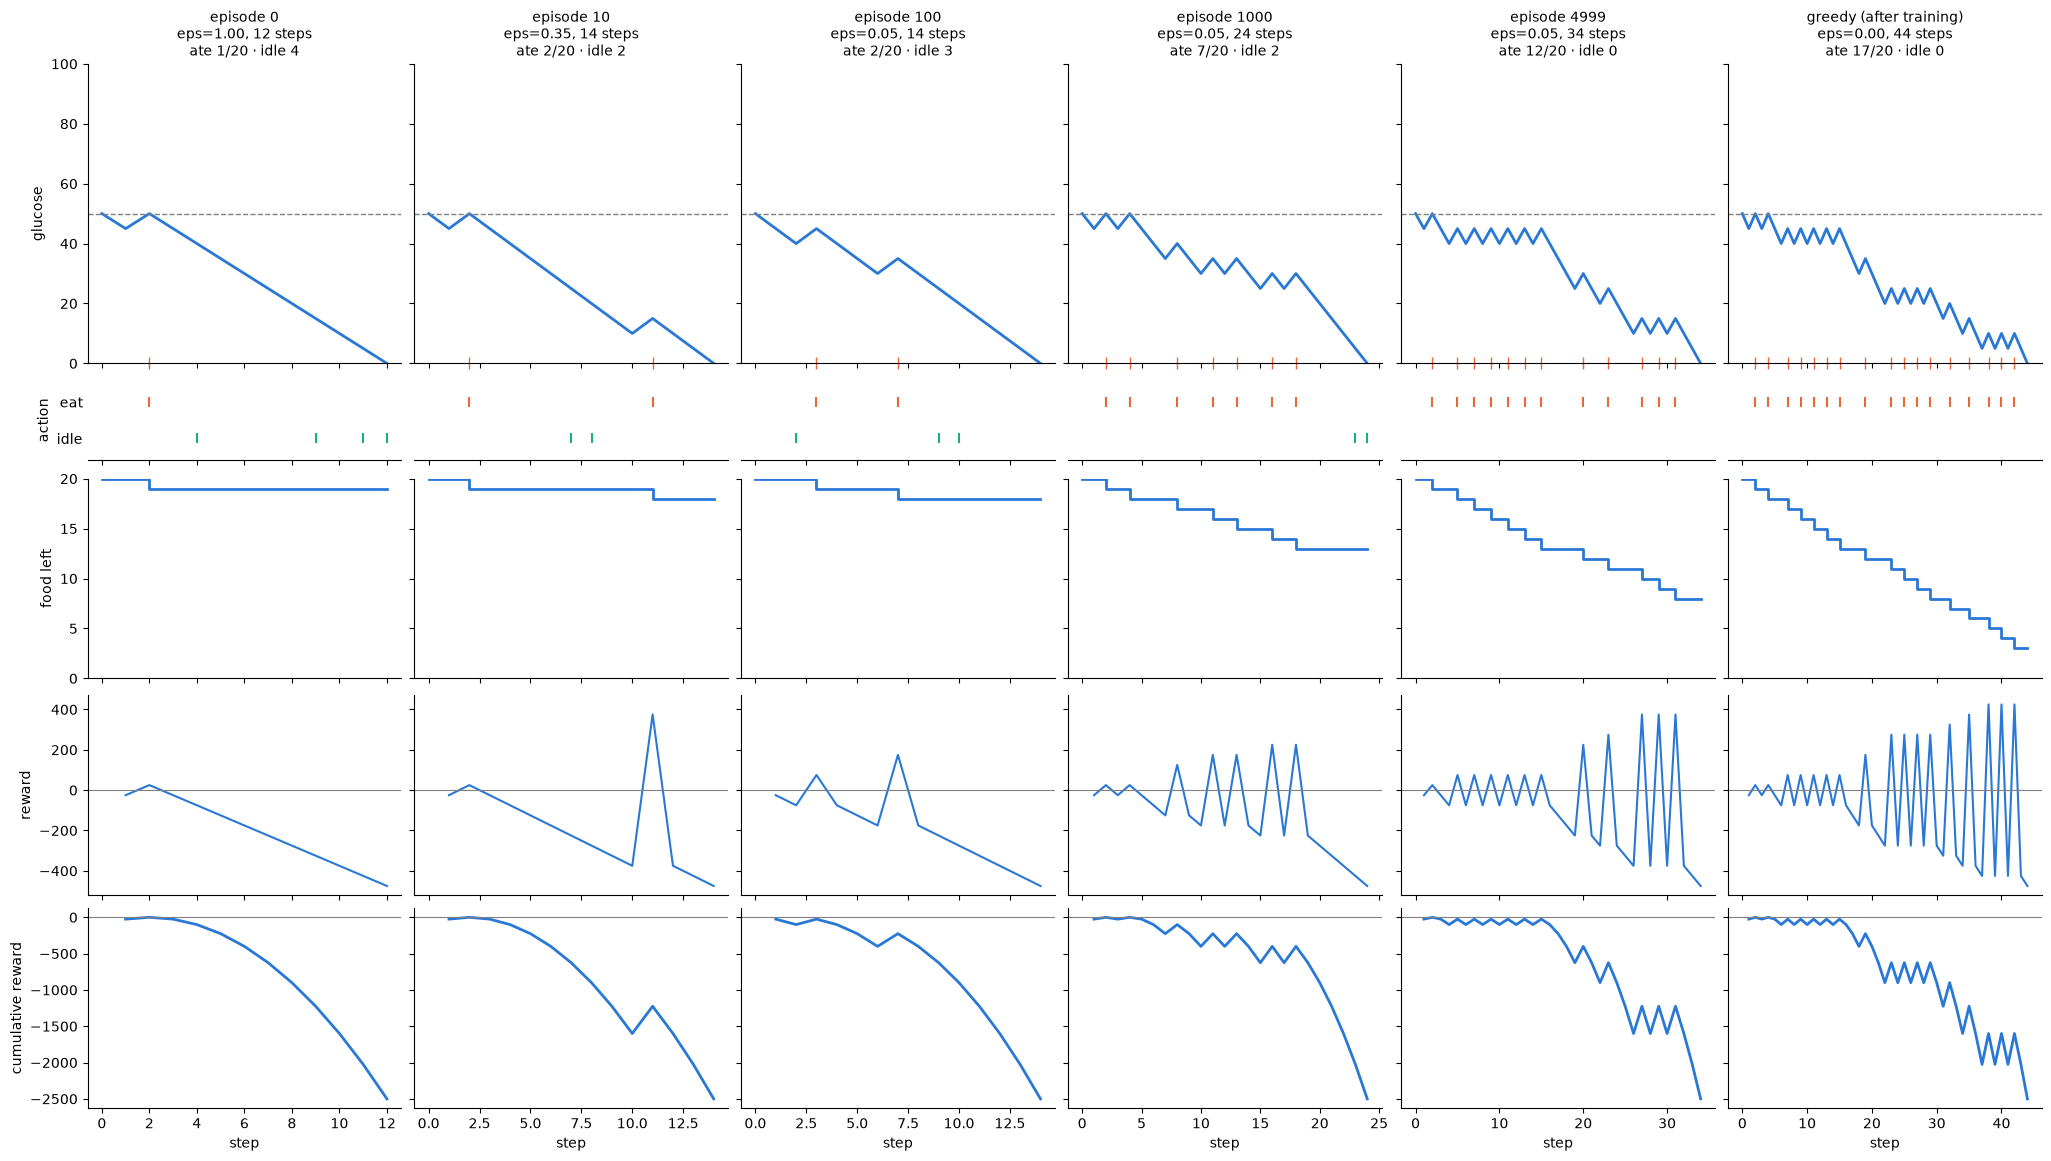

In [7]:
STRIP_CATS = ["eat", "idle"] # move is every other step, so it's left out of the strip


def plot_trajectories(trajs, env, titles=None, color="#2a78d6"):
    """
    trajs: dict of {label: trajectory dict from run_episode}
    """
    labels = list(trajs.keys())
    n = len(labels)
    fig, axes = plt.subplots(5, n, figsize=(3.4 * n, 11.5), sharex="col", sharey="row",
                             squeeze=False, gridspec_kw={"height_ratios": [3, 0.8, 2, 2, 2]}, layout="constrained")

    for col, label in enumerate(labels):
        traj = trajs[label]
        steps = np.arange(1, len(traj["reward"]) + 1)

        # glucose (index 0 = start of episode, before any step)
        ax = axes[0, col]
        ax.plot(np.arange(len(traj["glucose"])), traj["glucose"], color=color, linewidth=2)
        ax.axhline(env.glucose_target, color="gray", linestyle="--", linewidth=1)
        eat_steps = steps[traj["categories"] == "eat"]
        ax.plot(eat_steps, np.zeros_like(eat_steps), "|", color=CAT_COLORS["eat"], markersize=8,
                clip_on=False)
        ax.set_ylim(0, env.glucose_max)
        ax.set_title(titles[col] if titles else str(label), fontsize=10)

        # action strip: one row of ticks per category
        ax = axes[1, col]
        for i, cat in enumerate(STRIP_CATS):
            cat_steps = steps[traj["categories"] == cat]
            ax.plot(cat_steps, np.full(len(cat_steps), i), "|", color=CAT_COLORS[cat],
                    markersize=7, markeredgewidth=1.5)
        ax.set_ylim(len(STRIP_CATS) - 0.4, -0.6) # first category on top
        ax.set_yticks(range(len(STRIP_CATS)))
        ax.set_yticklabels(STRIP_CATS)
        ax.tick_params(axis="y", length=0)

        # food remaining (index 0 = start of episode)
        ax = axes[2, col]
        ax.plot(np.arange(len(traj["food_left"])), traj["food_left"], color=color, linewidth=2,
                drawstyle="steps-post")
        ax.set_ylim(0, env.n_food)

        # per-step reward
        ax = axes[3, col]
        ax.plot(steps, traj["reward"], color=color, linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.8)

        # cumulative reward
        ax = axes[4, col]
        ax.plot(steps, traj["cum_reward"], color=color, linewidth=2)
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_xlabel("step")

    axes[0, 0].set_ylabel("glucose")
    axes[1, 0].set_ylabel("action")
    axes[2, 0].set_ylabel("food left")
    axes[3, 0].set_ylabel("reward")
    axes[4, 0].set_ylabel("cumulative reward")
    for ax in axes.flat:
        ax.spines[["top", "right"]].set_visible(False)
    for ax in axes[1]:
        ax.spines["left"].set_visible(False)
    plt.savefig("../plots/trajectories.png", dpi=300)
    plt.show()


def episode_title(label, traj):
    counts = action_counts(traj)
    return (f"{label}\neps={traj['epsilon']:.2f}, {len(traj['reward'])} steps\n"
            f"ate {counts['eat']}/{len(traj['food_start'])} · idle {counts['idle']}")


plot_trajs = {f"episode {ep}": trajectories[ep] for ep in RECORD_EPISODES}
plot_trajs["greedy (after training)"] = greedy_traj
titles = [episode_title(k, v) for k, v in plot_trajs.items()]
plot_trajectories(plot_trajs, env, titles=titles)

## Episode maps: food and navigation
One panel per episode. Squares are the food placed at the start of the episode: **filled** = eaten (fill color = step it was eaten, on the same scale as the path), **hollow gray** = left over. The path is colored by step (light = early, dark = late); dots mark steps where the agent didn't move (IDLE, EAT, or walking into a wall). Each step is jittered slightly so repeated moves along the same edge don't hide each other.

`mode="heatmap"` replaces the path with how many steps the agent spent on each tile, which is easier to read for long episodes.

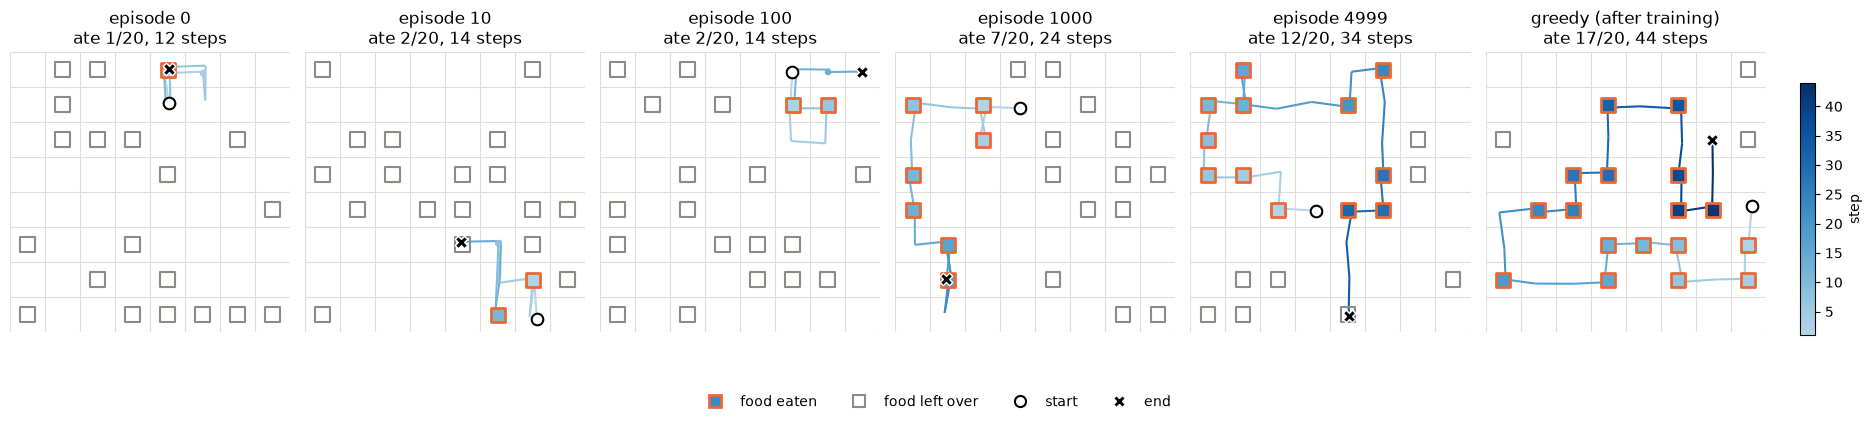

In [8]:
FOOD_LEFT_COLOR = "#8c8b85"
# light end of "Blues" is too pale to see on white, so start partway in
STEP_CMAP = LinearSegmentedColormap.from_list("steps", plt.get_cmap("Blues")(np.linspace(0.3, 1, 256)))


def plot_episode_maps(trajs, env, titles=None, mode="path", jitter=0.12, fname=None, seed=0):
    """
    trajs: dict of {label: trajectory dict from run_episode}
    mode: "path" (route colored by step) or "heatmap" (steps spent on each tile)
    """
    labels = list(trajs.keys())
    n = len(labels)
    g = env.grid_size
    rng = np.random.default_rng(seed) # jitter only; fixed so reruns look the same
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 4.2), squeeze=False)
    axes = axes[0]

    # shared across panels so a color means the same step everywhere;
    # spans the longest plotted episode (not max_steps) so short episodes aren't all pale
    step_norm = Normalize(1, max(len(trajs[label]["reward"]) for label in labels))
    if mode == "heatmap":
        visits = {}
        for label in labels:
            v = np.zeros((g, g))
            for r, c in trajs[label]["positions"]:
                v[r, c] += 1
            visits[label] = v
        visit_norm = Normalize(0, max(v.max() for v in visits.values()))

    for i, (ax, label) in enumerate(zip(axes, labels)):
        traj = trajs[label]
        pos = traj["positions"]
        steps = np.arange(1, len(pos))

        if mode == "heatmap":
            mappable = ax.imshow(visits[label], cmap="Blues", norm=visit_norm,
                                 extent=(-0.5, g - 0.5, g - 0.5, -0.5))
        else:
            # plot (x, y) = (col, row)
            xy = pos[:, ::-1].astype(float) + rng.uniform(-jitter, jitter, size=pos.shape)
            segments = np.stack([xy[:-1], xy[1:]], axis=1)
            mappable = LineCollection(segments, cmap=STEP_CMAP, norm=step_norm, linewidth=1.5)
            mappable.set_array(steps)
            ax.add_collection(mappable)
            stayed = np.all(pos[1:] == pos[:-1], axis=1)
            ax.scatter(xy[1:][stayed, 0], xy[1:][stayed, 1], c=steps[stayed], cmap=STEP_CMAP,
                       norm=step_norm, s=14, zorder=3)
            ax.scatter(*xy[0], marker="o", s=70, facecolor="white", edgecolor="black",
                       linewidth=1.5, zorder=5)
            ax.scatter(*xy[-1], marker="X", s=80, facecolor="black", edgecolor="white",
                       linewidth=1, zorder=5)

        # food: filled = eaten, hollow = left over
        for r, c in traj["food_start"]:
            if (r, c) in traj["eaten_at"]:
                face = (STEP_CMAP(step_norm(traj["eaten_at"][(r, c)])) if mode == "path"
                        else CAT_COLORS["eat"])
                ax.scatter(c, r, marker="s", s=110, facecolor=face, edgecolor=CAT_COLORS["eat"],
                           linewidth=2, zorder=4)
            else:
                ax.scatter(c, r, marker="s", s=110, facecolor="none", edgecolor=FOOD_LEFT_COLOR,
                           linewidth=1.5, zorder=4)

        # grid lines between tiles
        ax.set_xticks(np.arange(-0.5, g), minor=True)
        ax.set_yticks(np.arange(-0.5, g), minor=True)
        ax.grid(which="minor", color="#e0dfda", linewidth=0.8)
        ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
        ax.set_xlim(-0.5, g - 0.5)
        ax.set_ylim(g - 0.5, -0.5) # row 0 at the top, same as the grid array
        ax.set_aspect("equal")
        for spine in ax.spines.values():
            spine.set_visible(False)
        n_eaten = len(traj["eaten_at"])
        default_title = (f"{label}\nate {n_eaten}/{len(traj['food_start'])}, "
                         f"{len(traj['reward'])} steps")
        ax.set_title(titles[i] if titles else default_title)

    handles = [
        Line2D([], [], marker="s", linestyle="", markersize=9, markerfacecolor=STEP_CMAP(0.5) if mode == "path"
               else CAT_COLORS["eat"], markeredgecolor=CAT_COLORS["eat"], markeredgewidth=2, label="food eaten"),
        Line2D([], [], marker="s", linestyle="", markersize=9, markerfacecolor="none",
               markeredgecolor=FOOD_LEFT_COLOR, markeredgewidth=1.5, label="food left over"),
    ]
    if mode == "path":
        handles += [
            Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor="white",
                   markeredgecolor="black", markeredgewidth=1.5, label="start"),
            Line2D([], [], marker="X", linestyle="", markersize=9, markerfacecolor="black",
                   markeredgecolor="white", label="end"),
        ]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False)
    plt.tight_layout(rect=(0, 0.08, 0.93, 1))
    cax = fig.add_axes((0.94, 0.2, 0.008, 0.6))
    fig.colorbar(mappable, cax=cax, label="step" if mode == "path" else "steps on tile")
    if fname:
        plt.savefig(fname, dpi=300)
    plt.show()


plot_episode_maps(plot_trajs, env, fname="../plots/episode_maps.png")

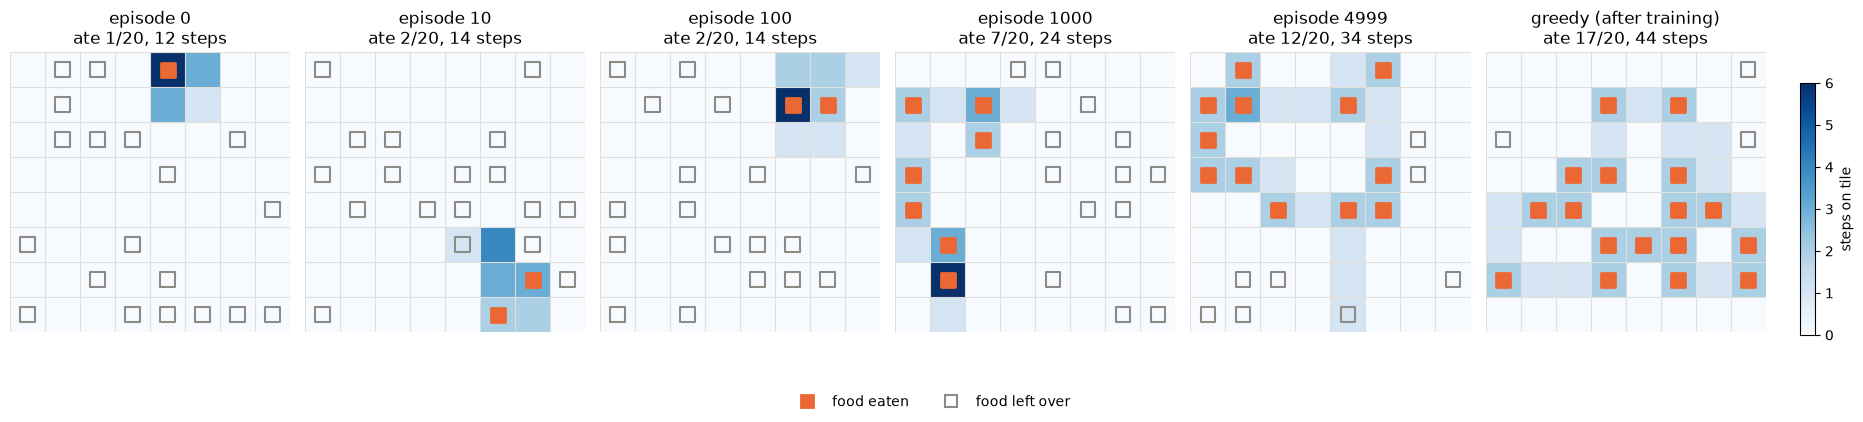

In [9]:
plot_episode_maps(plot_trajs, env, mode="heatmap", fname="../plots/episode_visit_heatmaps.png")

## Action mix and food left over across training
Left: for every episode we compute the share of its steps in each action category (shares, not counts, so episodes of different lengths are comparable). Single-episode shares are noisy (episodes are short, so one extra IDLE moves a share by several points), so the plotted line is the **mean share over a sliding window of the previous `WINDOW` episodes**. The first full window ends at episode `WINDOW - 1`, which is why the lines start there instead of at 0. Right: food left when the episode ends. Dotted lines mark the recorded episodes.

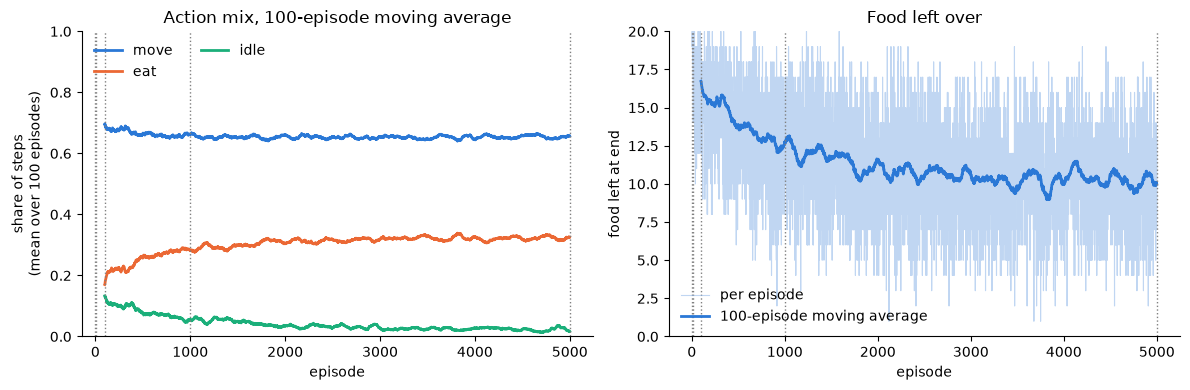

In [11]:
def moving_average(x, window=WINDOW):
    return np.convolve(x, np.ones(window) / window, mode="valid")


ma_x = np.arange(WINDOW - 1, N_EPISODES) # episode index at the end of each window
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for cat in ACTION_CATS:
    share = np.array(episode_action_counts[cat]) / lengths
    ma = moving_average(share)
    ax.plot(ma_x, ma, color=CAT_COLORS[cat], linewidth=2, label=cat)
ax.set_ylim(0, 1)
ax.set_ylabel(f"share of steps\n(mean over {WINDOW} episodes)")
ax.set_title(f"Action mix, {WINDOW}-episode moving average")
ax.legend(frameon=False, loc="upper left", ncol=2)

ax = axes[1]
food_left_end = np.array(episode_food_left)
ax.plot(food_left_end, color="#97bcea", linewidth=0.8, alpha=0.6, label="per episode")
ax.plot(ma_x, moving_average(food_left_end), color="#2a78d6", linewidth=2,
        label=f"{WINDOW}-episode moving average")
ax.set_ylim(0, env.n_food)
ax.set_ylabel("food left at end")
ax.set_title("Food left over")
ax.legend(frameon=False)

for ax in axes:
    for ep in RECORD_EPISODES:
        ax.axvline(ep, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("episode")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../plots/action_mix_food_left.png", dpi=300)
plt.show()